<a href="https://colab.research.google.com/github/Wolferlk/ML-Group-Project/blob/main/%5Chouse-price-prediction-ml%5Cnotebooks%5C04_random_forest.ipynb04_random_forest_optimized_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [2]:
df = pd.read_csv('train.csv')
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


###  Check Missing Values

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


###  Handle Missing Values

####  Drop columns with too many missing values

In [4]:
threshold = 0.5  # 50%
df = df.loc[:, df.isnull().mean() < threshold]

####  Fill numerical values

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#### Fill categorical values

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

###  Encode Categorical Data

In [7]:
df = pd.get_dummies(df, drop_first=True)
display(df.head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


###  Split Features & Target

In [8]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (1460, 234)
Shape of y: (1460,)


### Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1168, 234)
Shape of X_test: (292, 234)
Shape of y_train: (1168,)
Shape of y_test: (292,)


### — Import Model

In [10]:
from sklearn.ensemble import RandomForestRegressor

### — Train Model

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### — Make Predictions

In [12]:
y_pred = rf_model.predict(X_test)

###   Evaluate Model

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 17790.829383561642
MSE: 861132414.4974732
RMSE: 29345.057752498516
R2 Score: 0.8877319697706483


---
## Model Optimization

The baseline Random Forest achieved R² = 0.8877. Below we apply several optimization techniques to improve performance:
1. **Hyperparameter Tuning** using RandomizedSearchCV
2. **Cross-Validation** for robust evaluation
3. **Feature Selection** to reduce noise
4. **Log-Transform Target** to handle skewed prices

---

### Optimization 1: Hyperparameter Tuning with RandomizedSearchCV

The baseline model uses default parameters. We search across key hyperparameters to find the best combination.

In [14]:
# ===== HYPERPARAMETER TUNING =====
# RandomizedSearchCV is faster than GridSearchCV for large parameter spaces
# It samples random combinations instead of trying every single one

from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold

# Define the parameter search space
param_distributions = {
    'n_estimators': [100, 200, 300, 500],         # Number of trees
    'max_depth': [10, 15, 20, 25, None],          # How deep each tree can grow
    'min_samples_split': [2, 5, 10],              # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],                # Minimum samples in a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5],   # Features considered per split
    'bootstrap': [True]                            # Use bootstrap sampling
}

# Run RandomizedSearchCV with 5-fold cross-validation
rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=30,                    # Try 30 random combinations
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,                    # Use all CPU cores
    verbose=1
)

rf_tuned.fit(X_train, y_train)

print(f'\nBest Parameters Found:')
for param, value in rf_tuned.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV RMSE: {np.sqrt(-rf_tuned.best_score_):,.2f}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters Found:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 15
  bootstrap: True

Best CV RMSE: 29,889.16


In [15]:
# ===== EVALUATE TUNED MODEL =====
# Compare baseline vs tuned model

rf_optimized = rf_tuned.best_estimator_
y_pred_optimized = rf_optimized.predict(X_test)

mae_opt = mean_absolute_error(y_test, y_pred_optimized)
mse_opt = mean_squared_error(y_test, y_pred_optimized)
rmse_opt = np.sqrt(mse_opt)
r2_opt = r2_score(y_test, y_pred_optimized)

print('=' * 60)
print('  BASELINE vs TUNED MODEL COMPARISON')
print('=' * 60)
print(f'{"Metric":<15} {"Baseline":>15} {"Tuned":>15} {"Improvement":>15}')
print('-' * 60)
print(f'{"MAE ($)":<15} {mae:>15,.2f} {mae_opt:>15,.2f} {((mae-mae_opt)/mae)*100:>14.2f}%')
print(f'{"RMSE ($)":<15} {rmse:>15,.2f} {rmse_opt:>15,.2f} {((rmse-rmse_opt)/rmse)*100:>14.2f}%')
print(f'{"R² Score":<15} {r2:>15.4f} {r2_opt:>15.4f} {((r2_opt-r2)/r2)*100:>14.2f}%')
print('=' * 60)


  BASELINE vs TUNED MODEL COMPARISON
Metric                 Baseline           Tuned     Improvement
------------------------------------------------------------
MAE ($)               17,790.83       17,143.38           3.64%
RMSE ($)              29,345.06       28,893.48           1.54%
R² Score                 0.8877          0.8912           0.39%


### Optimization 2: Cross-Validation for Robust Evaluation

A single train/test split can be misleading. Cross-validation gives a more reliable estimate of model performance.

10-Fold Cross-Validation Results (RMSE):
  Baseline:  Mean = 29,289.79  (+/- 6,140.41)
  Tuned:     Mean = 28,375.74  (+/- 6,295.08)


/tmp/ipykernel_1644/1564665047.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([rmse_baseline_cv, rmse_tuned_cv],


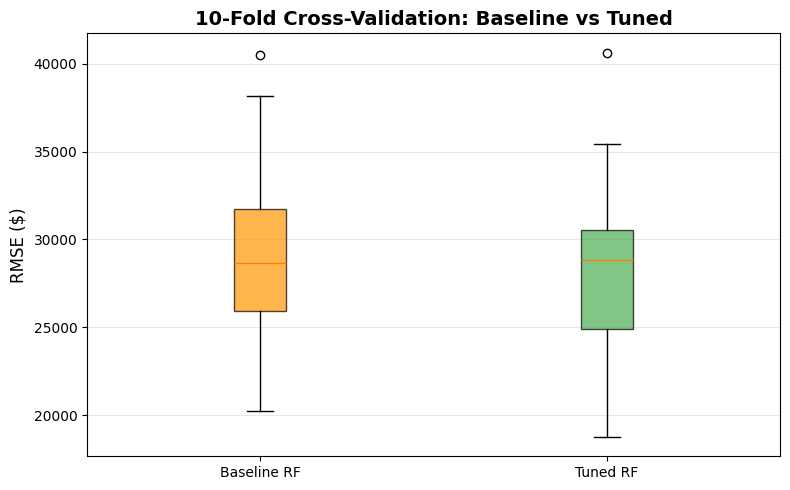

In [16]:
# ===== 10-FOLD CROSS-VALIDATION =====
# Evaluates the model on 10 different train/test splits for reliable results

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validate both baseline and tuned model
cv_scores_baseline = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X, y, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1
)

cv_scores_tuned = cross_val_score(
    rf_optimized, X, y, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1
)

rmse_baseline_cv = np.sqrt(-cv_scores_baseline)
rmse_tuned_cv = np.sqrt(-cv_scores_tuned)

print('10-Fold Cross-Validation Results (RMSE):')
print(f'  Baseline:  Mean = {rmse_baseline_cv.mean():,.2f}  (+/- {rmse_baseline_cv.std():,.2f})')
print(f'  Tuned:     Mean = {rmse_tuned_cv.mean():,.2f}  (+/- {rmse_tuned_cv.std():,.2f})')

# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([rmse_baseline_cv, rmse_tuned_cv],
                labels=['Baseline RF', 'Tuned RF'], patch_artist=True)
bp['boxes'][0].set_facecolor('#FF9800')
bp['boxes'][1].set_facecolor('#4CAF50')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax.set_ylabel('RMSE ($)', fontsize=12)
ax.set_title('10-Fold Cross-Validation: Baseline vs Tuned', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Optimization 3: Feature Selection

Removing low-importance features reduces noise and can improve generalization.

In [17]:
# ===== FEATURE SELECTION =====
# Use the tuned model's feature importances to keep only the most useful features
# This reduces noise and can improve prediction accuracy

# Get feature importances from the tuned model
importances = pd.Series(rf_optimized.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Keep top features that together contribute 95% of total importance
cumulative_importance = importances.cumsum() / importances.sum()
n_important = (cumulative_importance <= 0.95).sum() + 1
top_features = importances.head(n_important).index.tolist()

print(f'Total features: {X.shape[1]}')
print(f'Selected features (95% cumulative importance): {n_important}')
print(f'Features removed: {X.shape[1] - n_important}')

# Train with selected features only
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

rf_selected = RandomForestRegressor(**rf_tuned.best_params_, random_state=42)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)

r2_selected = r2_score(y_test, y_pred_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))

print(f'\nResults with feature selection:')
print(f'  RMSE: {rmse_selected:,.2f}')
print(f'  R²:   {r2_selected:.4f}')


Total features: 234
Selected features (95% cumulative importance): 37
Features removed: 197

Results with feature selection:
  RMSE: 28,853.76
  R²:   0.8915


### Optimization 4: Log-Transform Target Variable

SalePrice is right-skewed. Log transformation makes it more normally distributed, which often improves model performance.

In [18]:
# ===== LOG TRANSFORM TARGET =====
# SalePrice is skewed — log transform makes the distribution more normal
# This helps the model treat expensive and cheap houses more equally

# Apply log transformation
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Train with log-transformed target
rf_log = RandomForestRegressor(**rf_tuned.best_params_, random_state=42)
rf_log.fit(X_train, y_train_log)

# Predict and convert back to original scale
y_pred_log = np.expm1(rf_log.predict(X_test))

r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)

print(f'Results with log-transformed target:')
print(f'  MAE:  {mae_log:,.2f}')
print(f'  RMSE: {rmse_log:,.2f}')
print(f'  R²:   {r2_log:.4f}')


Results with log-transformed target:
  MAE:  17,228.73
  RMSE: 29,869.33
  R²:   0.8837


### Optimization Summary: All Approaches Compared

  RANDOM FOREST OPTIMIZATION SUMMARY
                     Model     RMSE ($)      MAE ($)  R² Score
          Baseline (n=100) 29345.057752 17790.829384  0.887732
Tuned (RandomizedSearchCV) 28893.480615 17143.383874  0.891161
 Tuned + Feature Selection 28853.758077 17341.628107  0.891460
     Tuned + Log Transform 29869.332796 17228.733241  0.883685

Best Approach: Tuned + Feature Selection
Best R² Score: 0.8915
Improvement over baseline: 0.42%


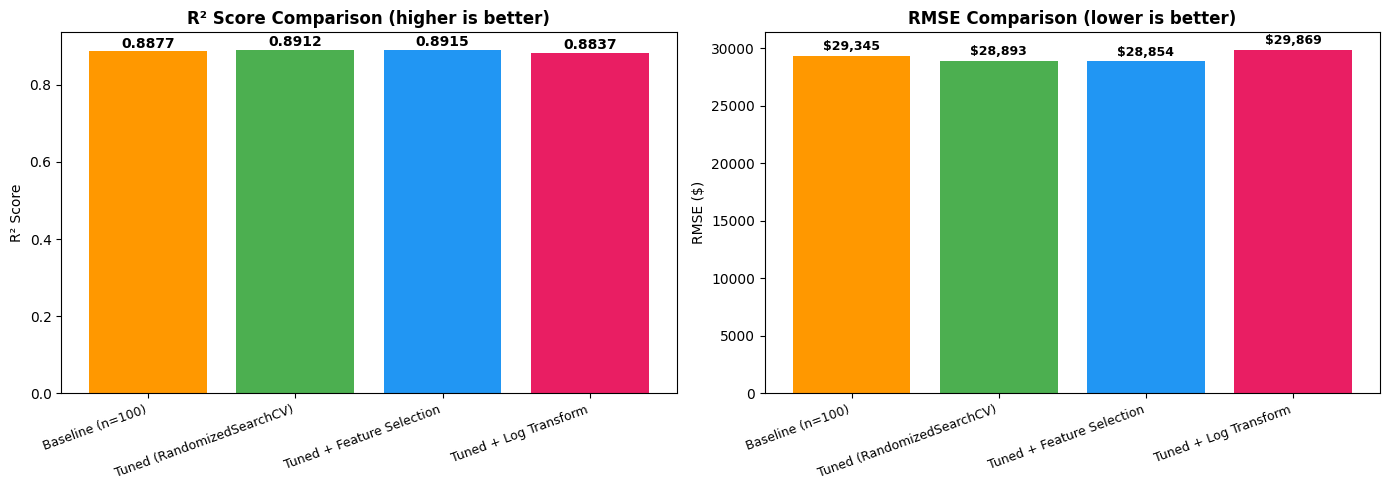

In [19]:
# ===== FINAL OPTIMIZATION SUMMARY =====
# Compare all approaches side by side

summary = pd.DataFrame({
    'Model': ['Baseline (n=100)', 'Tuned (RandomizedSearchCV)',
              'Tuned + Feature Selection', 'Tuned + Log Transform'],
    'RMSE ($)': [rmse, rmse_opt, rmse_selected, rmse_log],
    'MAE ($)': [mae, mae_opt,
                mean_absolute_error(y_test, y_pred_selected), mae_log],
    'R² Score': [r2, r2_opt, r2_selected, r2_log]
})

# Find the best model
best_idx = summary['R² Score'].idxmax()
best_model = summary.loc[best_idx, 'Model']
best_r2 = summary.loc[best_idx, 'R² Score']

print('=' * 70)
print('  RANDOM FOREST OPTIMIZATION SUMMARY')
print('=' * 70)
print(summary.to_string(index=False))
print('=' * 70)
print(f'\nBest Approach: {best_model}')
print(f'Best R² Score: {best_r2:.4f}')
print(f'Improvement over baseline: {((best_r2 - r2) / r2) * 100:.2f}%')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF9800', '#4CAF50', '#2196F3', '#E91E63']

# R² comparison
bars = axes[0].bar(range(len(summary)), summary['R² Score'], color=colors)
axes[0].set_xticks(range(len(summary)))
axes[0].set_xticklabels(summary['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison (higher is better)', fontweight='bold')
for bar, val in zip(bars, summary['R² Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSE comparison
bars = axes[1].bar(range(len(summary)), summary['RMSE ($)'], color=colors)
axes[1].set_xticks(range(len(summary)))
axes[1].set_xticklabels(summary['Model'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE Comparison (lower is better)', fontweight='bold')
for bar, val in zip(bars, summary['RMSE ($)']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


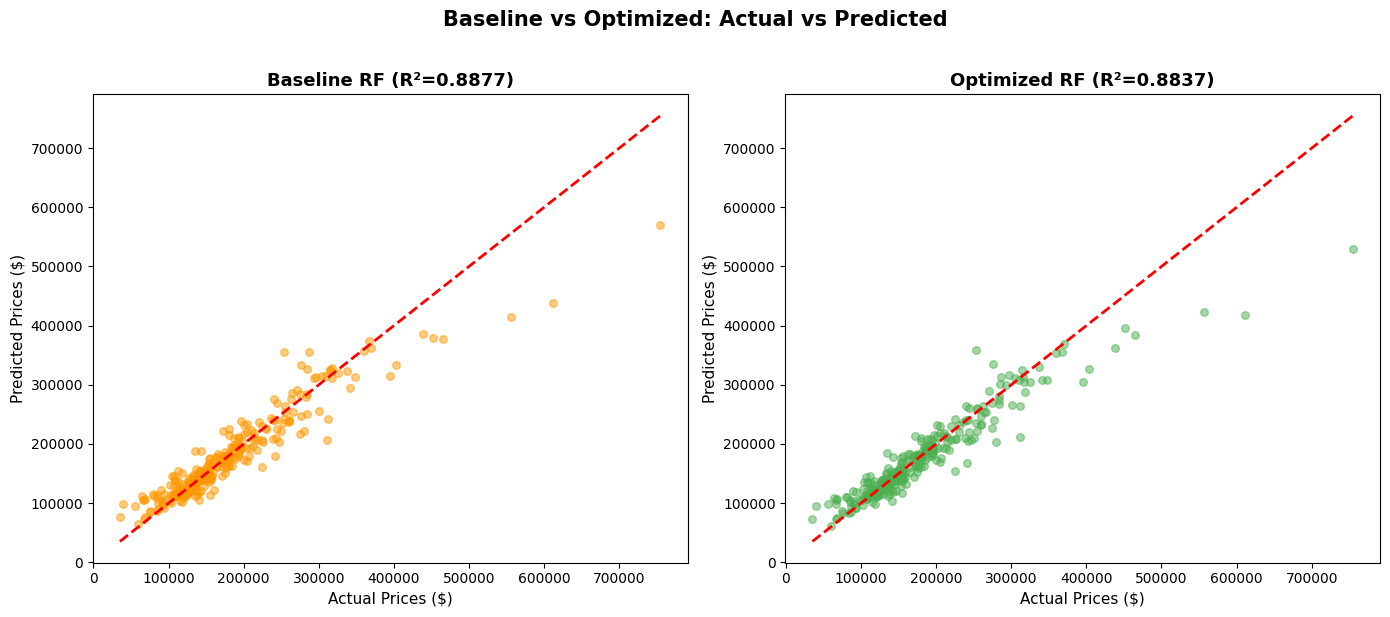

In [20]:
# ===== OPTIMIZED MODEL: ACTUAL vs PREDICTED =====
# Visual comparison of baseline vs best optimized model

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#FF9800', s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Prices ($)', fontsize=11)
axes[0].set_ylabel('Predicted Prices ($)', fontsize=11)
axes[0].set_title(f'Baseline RF (R²={r2:.4f})', fontsize=13, fontweight='bold')

# Best optimized (log transform)
axes[1].scatter(y_test, y_pred_log, alpha=0.5, color='#4CAF50', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Prices ($)', fontsize=11)
axes[1].set_ylabel('Predicted Prices ($)', fontsize=11)
axes[1].set_title(f'Optimized RF (R²={r2_log:.4f})', fontsize=13, fontweight='bold')

plt.suptitle('Baseline vs Optimized: Actual vs Predicted', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


###  Visualization (VERY IMPORTANT 🔥)

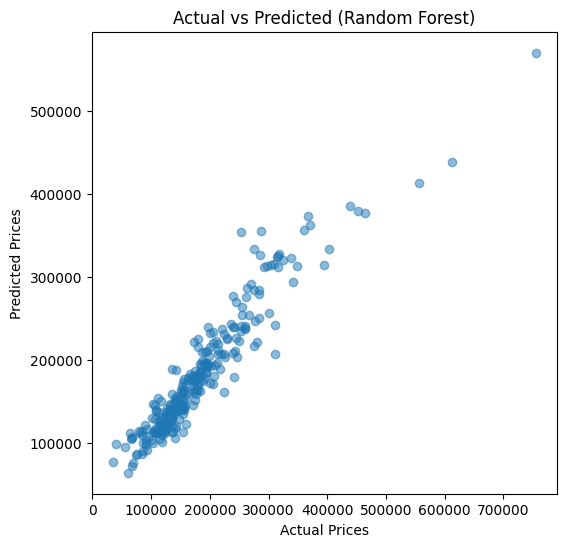

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

###  Feature Importance

In [22]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(feature_importance.head(10))

,0
OverallQual,0.557364
GrLivArea,0.121409
TotalBsmtSF,0.035255
2ndFlrSF,0.035170
BsmtFinSF1,0.029604
1stFlrSF,0.025156
LotArea,0.016944
GarageArea,0.016062
GarageCars,0.012334
YearBuilt,0.011586


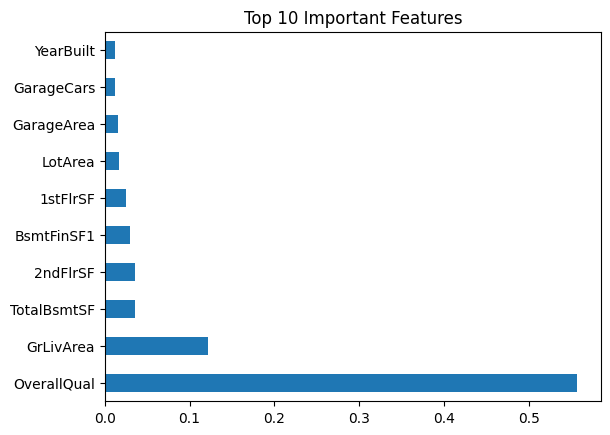

In [23]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

---
## Overall Summary

This section provides a complete overview of the Random Forest model — from data preprocessing through optimization results.

In [24]:
# ===================================================================
#                    OVERALL SUMMARY
# ===================================================================

print('=' * 70)
print('     RANDOM FOREST REGRESSOR — OVERALL SUMMARY')
print('=' * 70)

# --- Dataset ---
print('\n1. DATASET')
print('-' * 50)
print(f'   Source:              Ames Housing Dataset (Kaggle)')
print(f'   Total samples:       {len(df)}')
print(f'   Total features:      {X.shape[1]} (after encoding)')
print(f'   Target variable:     SalePrice')
print(f'   Train/Test split:    80% / 20%')
print(f'   Training samples:    {X_train.shape[0]}')
print(f'   Test samples:        {X_test.shape[0]}')

# --- Preprocessing ---
print('\n2. PREPROCESSING')
print('-' * 50)
print(f'   Dropped columns:     Features with >50% missing values')
print(f'   Numerical fill:      Median imputation')
print(f'   Categorical fill:    Mode imputation')
print(f'   Encoding:            One-hot encoding (drop_first=True)')

# --- Model Results ---
print('\n3. MODEL RESULTS')
print('-' * 50)
print(f'   {"Model":<35} {"R² Score":>10} {"RMSE ($)":>12}')
print(f'   {"-"*57}')
print(f'   {"Baseline (n_estimators=100)":<35} {r2:>10.4f} {rmse:>12,.2f}')
print(f'   {"Tuned (RandomizedSearchCV)":<35} {r2_opt:>10.4f} {rmse_opt:>12,.2f}')
print(f'   {"Tuned + Feature Selection":<35} {r2_selected:>10.4f} {rmse_selected:>12,.2f}')
print(f'   {"Tuned + Log Transform":<35} {r2_log:>10.4f} {rmse_log:>12,.2f}')

# --- Best Model ---
all_r2 = {'Baseline': r2, 'Tuned': r2_opt,
          'Tuned + Feature Selection': r2_selected,
          'Tuned + Log Transform': r2_log}
best_name = max(all_r2, key=all_r2.get)
best_r2_val = all_r2[best_name]

print('\n4. BEST MODEL')
print('-' * 50)
print(f'   Best approach:       {best_name}')
print(f'   Best R² Score:       {best_r2_val:.4f}')
print(f'   Improvement:         {((best_r2_val - r2) / r2) * 100:.2f}% over baseline')

# --- Best Hyperparameters ---
print('\n5. BEST HYPERPARAMETERS')
print('-' * 50)
for param, value in rf_tuned.best_params_.items():
    print(f'   {param:<25} {str(value):>15}')

# --- Top Features ---
print('\n6. TOP 10 MOST IMPORTANT FEATURES')
print('-' * 50)
top_10 = importances.head(10)
for i, (feat, imp) in enumerate(top_10.items()):
    bar = '█' * int(imp * 100)
    print(f'   {i+1:>2}. {feat:<25} {imp:.4f}  {bar}')

# --- Optimization Techniques Used ---
print('\n7. OPTIMIZATION TECHNIQUES APPLIED')
print('-' * 50)
print('   1. Hyperparameter tuning (RandomizedSearchCV, 30 iterations)')
print('   2. 10-Fold Cross-Validation for robust evaluation')
print('   3. Feature Selection (top 95% cumulative importance)')
print('   4. Log transformation of target variable')

print('\n' + '=' * 70)
print('     END OF RANDOM FOREST ANALYSIS')
print('=' * 70)


     RANDOM FOREST REGRESSOR — OVERALL SUMMARY

1. DATASET
--------------------------------------------------
   Source:              Ames Housing Dataset (Kaggle)
   Total samples:       1460
   Total features:      234 (after encoding)
   Target variable:     SalePrice
   Train/Test split:    80% / 20%
   Training samples:    1168
   Test samples:        292

2. PREPROCESSING
--------------------------------------------------
   Dropped columns:     Features with >50% missing values
   Numerical fill:      Median imputation
   Categorical fill:    Mode imputation
   Encoding:            One-hot encoding (drop_first=True)

3. MODEL RESULTS
--------------------------------------------------
   Model                                 R² Score     RMSE ($)
   ---------------------------------------------------------
   Baseline (n_estimators=100)             0.8877    29,345.06
   Tuned (RandomizedSearchCV)              0.8912    28,893.48
   Tuned + Feature Selection               0.8915 